# Plot : couple moteur / couple barillet vs temps

Ce notebook sert à générer le graphe utilisé dans le rapport pour justifier l'approximation (quasi-)linéaire sur une portion de la réserve de marche.



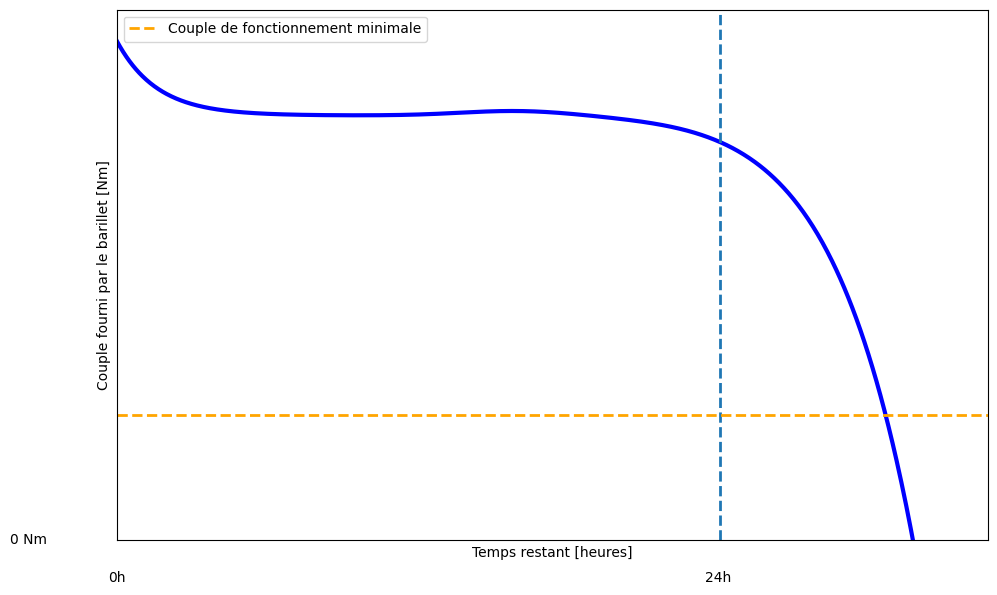

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Axe X
x = np.linspace(0, 60000, 1000)

# Fonction approchant la forme du graphe
y = (
    680
    + 120 * np.exp(-x / 3000)          # chute rapide au début
    - 750 * (x / 60000) ** 10          # chute forte vers 60k jusqu'à 0
    + 8 * np.exp(-((x - 30000) / 6000) ** 2)  # légère bosse au milieu
)

# Création du graphe
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, color='blue', linewidth=3)

# Ajouter la ligne verticale juste avant la chute
ax.axvline(x=45000, linestyle='--', linewidth=2)

# Ajouter la ligne horizontale pour le couple minimal
ax.axhline(y=200, color='orange', linestyle='--', linewidth=2, label='Couple de fonctionnement minimale')

# Limites des axes
ax.set_xlim(0, 65000)
ax.set_ylim(0, 850)

# Supprimer les graduations des axes
ax.set_xticks([])
ax.set_yticks([])

# Ajouter les titres des axes avec unités
ax.set_xlabel("Temps restant [heures]")
ax.set_ylabel("Couple fourni par le barillet [Nm]")

# Ajouter les valeurs sous les axes en utilisant les coordonnées de l'axe
ax.text(0, -0.08, '0h', fontsize=10, horizontalalignment='center', transform=ax.transAxes)
ax.text(0.69, -0.08, '24h', fontsize=10, horizontalalignment='center', transform=ax.transAxes)
ax.text(-0.08, 0, '0 Nm', fontsize=10, verticalalignment='center', horizontalalignment='right', transform=ax.transAxes)

# Ajouter la légende
ax.legend()

plt.tight_layout()